In [3]:
from models import ProductQuery, PhoneDeal

In [5]:
from langchain_openai import ChatOpenAI

from models import ProductQuery, QueryRoute

from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage

# from best_mobile_deal_finder_agent.models import PhoneDeal
# ---------------------------------------------------------
# LLM
# ---------------------------------------------------------

# llm = ChatOpenAI(
#     model=settings.openrouter_model,
#     api_key=settings.openrouter_api_key,
#     base_url=settings.openrouter_base_url,
#     temperature=0,
#     max_completion_tokens=1000,
# )

llm = ChatOpenAI(
    model="qwen3:8b",
    base_url="http://localhost:11434/v1",
    api_key="ollama",
    temperature=0,
)

# ---------------------------------------------------------
# Query Router
# ---------------------------------------------------------

router_llm = llm.with_structured_output(QueryRoute)


def route_query(
    user_query: str,
    messages: list[BaseMessage] | None = None,
) -> QueryRoute:
    """
    Determine whether the user wants:

    - deal: phone/deal search or recommendations
    - summarize: summary/recap of the conversation
    - mobile_info: general mobile-phone information

    Conversation history is used to understand follow-up queries.
    """

    messages = messages or []

    conversation = []

    for message in messages:
        conversation.append(f"{message.type}: {message.content}")

    history = "\n".join(conversation)

    response = router_llm.invoke(
        [
            {
                "role": "system",
                "content": """
    You classify mobile phone conversations.

    Return exactly ONE of these categories:

    1. deal
    2. summarize
    3. mobile_info


    =========================================================
    CATEGORY: summarize
    =========================================================

    Use "summarize" when the user wants a summary, recap,
    overview, or condensed version of the PREVIOUS conversation.

    This includes requests such as:

    - summarize our conversation
    - summarize our chat
    - summarize everything
    - give me a summary
    - what have we talked about?
    - what did we discuss?
    - recap our conversation
    - recap our chat
    - give me an overview of our discussion
    - summarize what we discussed about phones
    - summarize the conversation so far
    - what have we discussed so far?

    IMPORTANT:

    If the user explicitly asks to summarize, recap, review,
    or give an overview of the conversation/history, ALWAYS
    classify it as "summarize".

    Do NOT classify a summary request as "deal" just because
    the conversation contains phone deals.

    Do NOT classify a summary request as "mobile_info" just
    because the conversation contains mobile-phone information.


    =========================================================
    CATEGORY: deal
    =========================================================

    Use "deal" when the user wants to find, compare, calculate,
    or recommend a phone deal.

    This includes:

    - finding phones
    - finding prices
    - comparing prices
    - cheapest phone
    - best deal
    - best offer
    - discounts
    - retailer deals
    - phone recommendations based on budget
    - phones under a specific budget
    - comparing retailer prices
    - finding the cheapest retailer
    - asking for alternatives to a deal


    Examples:

    "Find me an iPhone"
    => deal

    "Which retailer has the cheapest iPhone 16?"
    => deal

    "Show me the best iPhone 16 deal"
    => deal

    "iPhone 16 under 75000"
    => deal

    "Find Samsung phones under ₹50,000"
    => deal

    "Is there a cheaper option?"
    => deal

    "Show me another retailer"
    => deal


    =========================================================
    CATEGORY: mobile_info
    =========================================================

    Use "mobile_info" when the user asks for factual or
    general information about mobile phones, brands, models,
    retailers, delivery, warranty, stock, specifications,
    availability, or related topics.

    Examples:

    "What brands are available?"
    => mobile_info

    "How many retailers sell phones?"
    => mobile_info

    "What brands and models are available?"
    => mobile_info

    "Does Retailer A charge delivery for iPhone 16?"
    => mobile_info

    "What is the battery capacity of the iPhone 16?"
    => mobile_info

    "When was the Samsung S25 released?"
    => mobile_info

    "Does this phone have wireless charging?"
    => mobile_info


    =========================================================
    FOLLOW-UP QUESTIONS
    =========================================================

    Use the conversation history to understand follow-up
    questions.

    If the current query is a continuation of a previous
    shopping/deal conversation, classify it as "deal" when
    the user is still discussing:

    - prices
    - phones
    - retailers
    - budgets
    - recommendations
    - deals
    - alternatives

    For example:

    Previous:
    "I want an iPhone under ₹70,000"

    Current:
    "Can you find a cheaper one?"

    => deal


    If the current query is a continuation of a factual/mobile
    information conversation, classify it as "mobile_info".

    For example:

    Previous:
    "Does the iPhone 16 support MagSafe?"

    Current:
    "What about the iPhone 15?"

    => mobile_info


    =========================================================
    SUMMARY HAS PRIORITY
    =========================================================

    If the current query asks to summarize, recap, condense,
    review, or give an overview of the previous conversation,
    ALWAYS return "summarize", regardless of what the previous
    conversation was about.

    For example:

    Previous:
    "Find me an iPhone 16 under ₹70,000"

    Current:
    "Summarize our conversation"

    => summarize


    Previous:
    "Does the iPhone 16 support MagSafe?"

    Current:
    "What have we talked about so far?"

    => summarize


    Previous:
    "Find Samsung phones under ₹50,000"

    Current:
    "Give me a summary of everything"

    => summarize


    =========================================================
    OUTPUT
    =========================================================

    Return exactly ONE category:

    deal

    summarize

    mobile_info

    Do not return explanations.
    """,
            },
            {
                "role": "user",
                "content": f"""
    Conversation history:

    {history}

    Current user query:

    {user_query}
    """,
            },
        ]
    )

    return response


# ---------------------------------------------------------
# Product Query Extraction
# ---------------------------------------------------------

structured_llm = llm.with_structured_output(ProductQuery)


def extract_product_details(user_query: str, messages) -> ProductQuery:

    history = "\n".join(
        f"{message.type}: {message.content}" for message in messages[:-1]
    )

    response = structured_llm.invoke(
        [
            {
                "role": "system",
                "content": f"""
You extract structured phone requirements from a user's request.

Use the previous conversation when the current request
is a follow-up to an earlier request.

Previous conversation:

{history}

Return:

- brand
- memory
- storage
- budget

Rules:

- brand means phone manufacturer.
- memory means RAM.
- storage means internal storage.
- budget means the maximum effective price the user is willing to pay.

Examples:

"Samsung 8GB 256GB"
brand = Samsung
memory = 8GB
storage = 256GB

"iPhone 16 256GB"
brand = Apple
memory = null
storage = 256GB

"under 70000"
budget = 70000

If the current request doesn't explicitly repeat
a requirement, use the previous conversation when
appropriate.

Do not invent requirements.
""",
            },
            {
                "role": "user",
                "content": user_query,
            },
        ]
    )

    return response


def generate_deal_response(
    user_query: str,
    extracted_query: ProductQuery,
    best_deal,
    second_best_deal,
    third_best_deal,
    messages,
):

    best_deal_text = (
        best_deal.model_dump_json() if best_deal else "No available deal found."
    )

    second_best_deal_text=(
        second_best_deal.model_dump_json() if second_best_deal else "No available deal found."
    )

    third_best_deal_text=(
            third_best_deal.model_dump_json() if third_best_deal else "No available deal found."
        )

    # alternatives_text = "\n".join(deal.model_dump_json() for deal in alternatives)

    prompt = f"""
You are a helpful mobile phone deal assistant.

Current user request:

{user_query}

Extracted requirements:

{extracted_query.model_dump_json()}

Best available deal:

{best_deal_text}

Second best deal:

{second_best_deal_text}

third best deal:

{third_best_deal_text}

Rules:

1. Use the conversation history to understand follow-up questions.

2. If the user refers to something previously discussed,
   use the previous conversation to resolve the reference.

3. Do not invent information, be factual while interpreting bank offers,discount, cash back, delivery charges,exchange bonus,etc.

4. The effective_price provided by the database is the
   authoritative deal price.

5. Do not recalculate effective_price.

6. If there is no matching available deal, clearly say so.

7. Keep the response concise.

8. If the user asks to summarize the conversation,
   summarize the conversation using the previous messages.
"""

    # Don't pass the current user message twice.
    previous_messages = messages[:-1]

    response = llm.invoke(
        [
            SystemMessage(content=prompt),
            *previous_messages,
            HumanMessage(content=user_query),
        ]
    )

    return response.content


In [9]:
from pydantic_settings import BaseSettings, SettingsConfigDict


class Settings(BaseSettings):
    # LLM configuration
    openrouter_base_url: str
    openrouter_model: str
    openrouter_api_key: str

    # PostgreSQL configuration
    db_host: str
    db_port: int = 5432
    db_name: str
    db_user: str
    db_password: str

    model_config = SettingsConfigDict(
        env_file=".env",
        env_file_encoding="utf-8",
        extra="ignore",
    )


settings = Settings()


In [11]:
import psycopg
from psycopg.rows import dict_row



def get_connection():
    return psycopg.connect(
        host=settings.db_host,
        port=settings.db_port,
        dbname=settings.db_name,
        user=settings.db_user,
        password=settings.db_password,
        row_factory=dict_row,
    )


In [12]:
from typing import Literal

from pydantic import BaseModel, Field


class QueryRoute(BaseModel):
    route: Literal[
        "deal",
        "summarize",
        "mobile_info"
    ]

class ProductQuery(BaseModel):
    brand: str | None = None
    # memory: Optional[str] = None
    memory: str | None = None
    storage:str | None = None
    budget: float | None = None
    
class PhoneDeal(BaseModel):
    retailer: str
    brand: str
    model: str
    memory: str
    storage: str
    mrp: float
    selling_price: float
    discount: float = 0
    cashback: float = 0
    bank_offer: float = 0
    exchange_bonus: float = 0
    delivery_charge: float = 0
    availability: bool
    stock_count: int = 0
    warranty: str = "1 year"
    effective_price: float = 0

class DealResult(BaseModel):
    query: ProductQuery
    best_deal: PhoneDeal | None = None
    alternatives: list[PhoneDeal] = Field(default_factory=list)
    message: str




In [13]:



BASE_DEAL_QUERY = """
    FROM retailer_data
    WHERE availability = 't'
      AND stock_count > 0
      AND effective_price IS NOT NULL
"""


def search_deals(query: ProductQuery) -> list[PhoneDeal]:

    sql = """
        SELECT
            retailer,
            brand,
            model,
            memory,
            storage,
            mrp,
            selling_price,
            discount,
            cashback,
            bank_offer,
            exchange_bonus,
            delivery_charge,
            availability,
            stock_count,
            warranty,
            effective_price
    """ + BASE_DEAL_QUERY

    params = []

    if query.brand:
        sql += " AND LOWER(brand) = LOWER(%s)"
        params.append(query.brand)

    if query.memory:
        sql += " AND LOWER(memory) = LOWER(%s)"
        params.append(query.memory)

    if query.storage:
        sql += " AND LOWER(storage) = LOWER(%s)"
        params.append(query.storage)

    # Budget = maximum effective price
    if query.budget is not None:
        sql += " AND effective_price <= %s"
        params.append(query.budget)

    sql += """
        ORDER BY effective_price ASC
    """

    with get_connection() as conn:
        rows = conn.execute(
            sql,
            params
        ).fetchall()

    return [
        PhoneDeal(**row)
        for row in rows
    ]


def get_best_deal(query: ProductQuery) -> PhoneDeal | None:

    sql = """
        SELECT
            retailer,
            brand,
            model,
            memory,
            storage,
            mrp,
            selling_price,
            discount,
            cashback,
            bank_offer,
            exchange_bonus,
            delivery_charge,
            availability,
            stock_count,
            warranty,
            effective_price
    """ + BASE_DEAL_QUERY

    params = []

    if query.brand:
        sql += " AND LOWER(brand) = LOWER(%s)"
        params.append(query.brand)

    if query.memory:
        sql += " AND LOWER(memory) = LOWER(%s)"
        params.append(query.memory)

    if query.storage:
        sql += " AND LOWER(storage) = LOWER(%s)"
        params.append(query.storage)

    # Budget = maximum effective price
    if query.budget is not None:
        sql += " AND effective_price <= %s"
        params.append(query.budget)

    sql += """
        ORDER BY effective_price ASC
        LIMIT 1
    """

    with get_connection() as conn:
        row = conn.execute(
            sql,
            params
        ).fetchone()

    if not row:
        return None

    return PhoneDeal(**row)



In [15]:
import sqlite3

from langgraph.checkpoint.sqlite import SqliteSaver

# ---------------------------------------------------------
# SQLite database
# ---------------------------------------------------------

DB_PATH = "chat_memory.sqlite"


# ---------------------------------------------------------
# SQLite connection
# ---------------------------------------------------------

conn = sqlite3.connect(
    DB_PATH,
    check_same_thread=False,
)


# ---------------------------------------------------------
# LangGraph checkpointer
# ---------------------------------------------------------

memory = SqliteSaver(conn)





In [16]:
from typing import TypedDict, List, Optional

from langgraph.graph import StateGraph, START, END


# from llm import (
#     extract_product_details,
#     generate_deal_response
# )
# from services.deals import (
#     search_deals,
#     get_best_deal
# )
# from memory import memory


class GraphState(TypedDict, total=False):

    user_query: str

    extracted_query: ProductQuery

    deals: List[PhoneDeal]

    best_deal: Optional[PhoneDeal]

    alternatives: List[PhoneDeal]

    conversation_context: List[str]

    response: str


# ---------------------------------------------------------
# Node 1: Extract structured product requirements
# ---------------------------------------------------------

def extract_node(state: GraphState):

    query = extract_product_details(
        state["user_query"]
    )

    return {
        "extracted_query": query
    }


# ---------------------------------------------------------
# Node 2: Search retailer data
# ---------------------------------------------------------

def retailer_search_node(state: GraphState):

    deals = search_deals(
        state["extracted_query"]
    )

    return {
        "deals": deals
    }


# ---------------------------------------------------------
# Node 3: Select best available deal
# ---------------------------------------------------------

def best_deal_node(state: GraphState):

    deals = state.get("deals", [])

    best = get_best_deal(deals)

    available = [
        deal
        for deal in deals
        if deal.availability and deal.stock_count > 0
    ]

    alternatives = sorted(
        available,
        key=lambda deal: deal.effective_price
    )

    if best:
        alternatives = [
            deal
            for deal in alternatives
            if deal.retailer != best.retailer
        ]

    return {
        "best_deal": best,
        "alternatives": alternatives
    }


# ---------------------------------------------------------
# Node 4: Generate natural-language response
# ---------------------------------------------------------

def response_node(state: GraphState):

    response = generate_deal_response(
        user_query=state["user_query"],
        extracted_query=state["extracted_query"],
        best_deal=state.get("best_deal"),
        alternatives=state.get("alternatives", []),
        conversation_context=state.get(
            "conversation_context",
            []
        ),
    )

    return {
        "response": response
    }


# ---------------------------------------------------------
# Build graph
# ---------------------------------------------------------

builder = StateGraph(GraphState)

builder.add_node(
    "extract",
    extract_node
)

builder.add_node(
    "search_retailers",
    retailer_search_node
)

builder.add_node(
    "select_best_deal",
    best_deal_node
)

builder.add_node(
    "generate_response",
    response_node
)

builder.add_edge(
    START,
    "extract"
)

builder.add_edge(
    "extract",
    "search_retailers"
)

builder.add_edge(
    "search_retailers",
    "select_best_deal"
)

builder.add_edge(
    "select_best_deal",
    "generate_response"
)

builder.add_edge(
    "generate_response",
    END
)


graph = builder.compile(
    checkpointer=memory
)


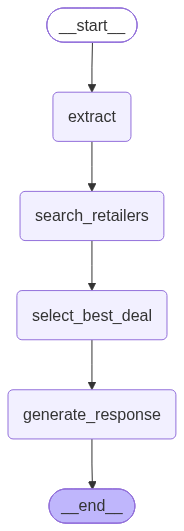

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [18]:
from typing import List, Optional
from langgraph.graph import StateGraph, START, END, MessagesState

# from app.models import ProductQuery, PhoneDeal
# from app.llm import (
#     route_query,
#     extract_product_details,
#     generate_deal_response
# )
# from app.mobile_info_agent import mobile_data_agent
# from app.services.deals import (
#     search_deals,
#     get_best_deal
# )
# from app.memory import memory
from langchain_core.messages import AIMessage

# class GraphState(TypedDict, total=False):

#     user_query: str

#     route: str

#     extracted_query: ProductQuery

#     deals: List[PhoneDeal]

#     best_deal: Optional[PhoneDeal]

#     alternatives: List[PhoneDeal]

#     conversation_context: List[str]

#     response: str


    # user_query: str

    # route: str

    # extracted_query: dict

    # deals: list[dict]

    # best_deal: Optional[dict]

    # alternatives: list[dict]

    # conversation_context: list[str]

    # response: str

class GraphState(MessagesState):

    user_query: str
    route: str
    extracted_query: ProductQuery
    deals: List[PhoneDeal]
    best_deal: Optional[PhoneDeal]
    alternatives: List[PhoneDeal]
    response: str



def route_node(state: GraphState):

    result = route_query(
        state["user_query"]
    )

    print({
        "route": result.route
    })

    print("*" * 100)

    return {
        "route": result.route
    }





def mobile_info_node(state: GraphState):

    response = mobile_data_agent(
        state["user_query"]
    )

    return {
        "response": response
    }

def route_after_classification(state: GraphState):

    if state["route"] == "deal":
        return "extract"

    return "mobile_info"

# ---------------------------------------------------------
# Node 1: Extract structured product requirements
# ---------------------------------------------------------

# def extract_node(state: GraphState):

#     query = extract_product_details(
#         state["user_query"]
#     )

#     print({"details_extracted_from_query": query})
#     print("*"*100)

#     return {
#         "extracted_query": query
#     }

def extract_node(state: GraphState):

    query = extract_product_details(
        state["user_query"]
    )

    print({
        "details_extracted_from_query": query.model_dump()
    })

    print("*" * 100)

    if query.budget is None:
        return {
            "extracted_query": query,
            "response": (
                "Please provide your mobile phone budget "
                "before I search for the best deal. "
                "For example: 'iPhone 16 under ₹70,000'."
            )
        }

    return {
        "extracted_query": query
    }


def after_extract(state: GraphState):

    query = state["extracted_query"]

    if query.budget is None:
        return "missing_budget"

    return "search"

# def extract_node(state: GraphState):

#     query = extract_product_details(
#         state["user_query"]
#     )

#     print({"details_extracted_from_query": query.model_dump()})
#     print("*"*100)

#     return {
#         "extracted_query": query.model_dump()
#     }



# ---------------------------------------------------------
# Node 2: Search retailer data
# ---------------------------------------------------------

def retailer_search_node(state: GraphState):

    deals = search_deals(
        state["extracted_query"]
    )

    # print({"searched_deals": deals})
    # print("*"*100)

    return {
        "deals": deals
    }

# def retailer_search_node(state: GraphState):

#     query = ProductQuery(
#         **state["extracted_query"]
#     )

#     print({"retailer_search_node":query})
#     print("*"*100)
#     deals = search_deals(query)

#     return {
#         "deals": [
#             deal.model_dump()
#             for deal in deals
#         ]
#     }



# ---------------------------------------------------------
# Node 3: Select best available deal
# ---------------------------------------------------------

# def best_deal_node(state: GraphState):

#     deals = state.get("deals", [])

#     best = get_best_deal(deals)

#     available = [
#         deal
#         for deal in deals
#         if deal.availability and deal.stock_count > 0
#     ]

#     alternatives = sorted(
#         available,
#         key=lambda deal: deal.effective_price
#     )

#     if best:
#         alternatives = [
#             deal
#             for deal in alternatives
#             if deal.retailer != best.retailer
#         ]

#     return {
#         "best_deal": best,
#         "alternatives": alternatives
#     }

def best_deal_node(state: GraphState):

    deals = state.get("deals", [])

    available = [
        deal
        for deal in deals
        # if deal.availability and deal.stock_count > 0
    ]

    available.sort(
        key=lambda deal: deal.effective_price
    )

    if not available:
        return {
            "best_deal": None,
            "alternatives": []
        }

    best = available[0]

    # Two alternatives from different retailers
    alternatives = []

    used_retailers = {best.retailer}

    for deal in available[1:]:

        if deal.retailer in used_retailers:
            continue

        alternatives.append(deal)
        used_retailers.add(deal.retailer)

        if len(alternatives) == 2:
            break

    return {
        "best_deal": best,
        "alternatives": alternatives
    }



# ---------------------------------------------------------
# Node 4: Generate natural-language response
# ---------------------------------------------------------

# def response_node(state: GraphState):

#     response = generate_deal_response(
#         user_query=state["user_query"],
#         extracted_query=state["extracted_query"],
#         best_deal=state.get("best_deal"),
#         alternatives=state.get("alternatives", []),
#         conversation_context=state.get(
#             "conversation_context",
#             []
#         ),
#     )

#     return {
#         "response": response
#     }

def response_node(state: GraphState):

    response = generate_deal_response(
        user_query=state["user_query"],
        extracted_query=state["extracted_query"],
        best_deal=state.get("best_deal"),
        alternatives=state.get("alternatives", []),
        messages=state.get("messages", []),
    )

    return {
        "response": response,
        "messages": [
            AIMessage(content=response)
        ],
    }



# ---------------------------------------------------------
# Build graph
# ---------------------------------------------------------

builder = StateGraph(GraphState)

builder.add_node(
    "route",
    route_node
)

builder.add_node(
    "extract",
    extract_node
)

builder.add_node(
    "missing_budget",
    lambda state: {
        "response": (
            "Please provide your mobile phone budget "
            "before I search for the best deal. "
            "For example: 'Find me the best iPhone under ₹70,000'."
        )
    }
)


builder.add_node(
    "search_retailers",
    retailer_search_node
)

builder.add_node(
    "select_best_deal",
    best_deal_node
)

builder.add_node(
    "generate_response",
    response_node
)

builder.add_node(
    "mobile_info",
    mobile_info_node
)

# ---------------------------------------------------------
# Build edges
# ---------------------------------------------------------

builder.add_edge(
    START,
    "route"
)

builder.add_conditional_edges(
    "route",
    route_after_classification,
    {
        "extract": "extract",
        "mobile_info": "mobile_info",
    }
)

builder.add_conditional_edges(
    "extract",
    after_extract,
    {
        "search": "search_retailers",
        "missing_budget": "missing_budget",
    }
)

builder.add_edge(
    "missing_budget",
    END
)


builder.add_edge(
    "search_retailers",
    "select_best_deal"
)

builder.add_edge(
    "select_best_deal",
    "generate_response"
)

builder.add_edge(
    "generate_response",
    END
)

builder.add_edge(
    "mobile_info",
    END
)



graph = builder.compile(
    checkpointer=memory
)


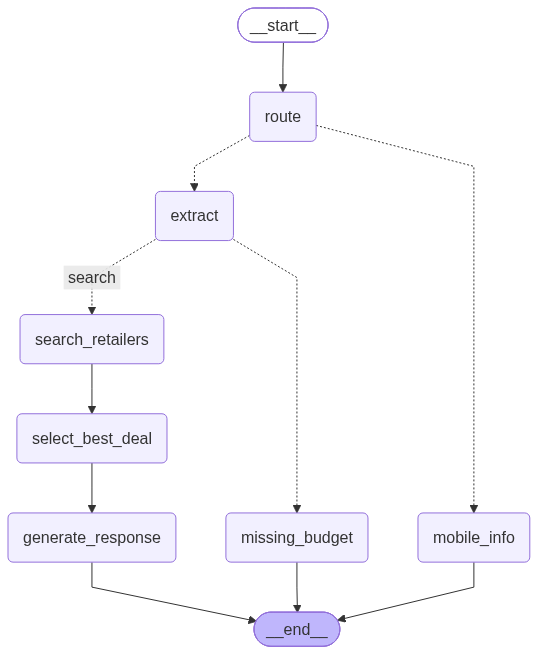

In [19]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [20]:
from typing import List, Optional

from langgraph.graph import StateGraph, START, END, MessagesState

# from app.models import ProductQuery, PhoneDeal

# from app.llm import (
#     route_query,
#     extract_product_details,
#     generate_deal_response,
#     generate_chat_summary,
# )

# from app.mobile_info_agent import mobile_data_agent

# from app.services.deals import (
#     search_deals,
#     get_best_deal,
# )

# from app.memory import (
#     memory,
#     get_chat_history,
# )

from langchain_core.messages import AIMessage


class GraphState(MessagesState):

    user_query: str
    route: str

    extracted_query: ProductQuery

    deals: List[PhoneDeal]

    best_deal: Optional[PhoneDeal]

    alternatives: List[PhoneDeal]

    response: str


# ---------------------------------------------------------
# Router
# ---------------------------------------------------------

def route_node(state: GraphState):

    messages = state.get("messages", [])

    result = route_query(
        user_query=state["user_query"],
        messages=messages[-10:],
    )

    print({
        "route": result.route
    })

    print("*" * 100)

    return {
        "route": result.route
    }


def route_after_classification(state: GraphState):

    if state["route"] == "deal":
        return "extract"

    if state["route"] == "summarize":
        return "summarize"

    return "mobile_info"


# ---------------------------------------------------------
# Summarization
# ---------------------------------------------------------

# def summarize_node(state: GraphState):

#     thread_id = state["user_id"]

#     history = get_chat_history(thread_id)

#     if not history:

#         response = (
#             "I don't have any previous conversation history "
#             "to summarize."
#         )

#         return {
#             "response": response,
#             "messages": [
#                 AIMessage(content=response)
#             ],
#         }

#     summary = generate_chat_summary(history)

#     return {
#         "response": summary,
#         "messages": [
#             AIMessage(content=summary)
#         ],
#     }

from langchain_core.runnables import RunnableConfig
def summarize_node(
    state: GraphState,
    config: RunnableConfig,
):

    thread_id = config["configurable"]["thread_id"]

    history = get_chat_history(thread_id)

    if not history:
        response = (
            "I don't have any previous conversation history "
            "to summarize."
        )

        return {
            "response": response,
            "messages": [
                AIMessage(content=response)
            ],
        }

    summary = generate_chat_summary(history)

    return {
        "response": summary,
        "messages": [
            AIMessage(content=summary)
        ],
    }


# ---------------------------------------------------------
# Mobile information
# ---------------------------------------------------------

def mobile_info_node(state: GraphState):

    response = mobile_data_agent(
        state["user_query"]
    )

    return {
        "response": response,
        "messages": [
            AIMessage(content=response)
        ],
    }


# ---------------------------------------------------------
# Deal extraction
# ---------------------------------------------------------

def extract_node(state: GraphState):

    query = extract_product_details(
        state["user_query"],
        state.get("messages", [])
    )

    print({
        "details_extracted_from_query": query.model_dump()
    })

    print("*" * 100)

    return {
        "extracted_query": query
    }


def after_extract(state: GraphState):

    query = state["extracted_query"]

    if query.budget is None:
        return "missing_budget"

    return "search"


def missing_budget_node(state: GraphState):

    response = (
        "Please provide your mobile phone budget "
        "before I search for the best deal. "
        "For example: 'iPhone 16 under ₹70,000'."
    )

    return {
        "response": response,
        "messages": [
            AIMessage(content=response)
        ],
    }


# ---------------------------------------------------------
# Retailer search
# ---------------------------------------------------------

def retailer_search_node(state: GraphState):

    deals = search_deals(
        state["extracted_query"]
    )

    return {
        "deals": deals
    }


# ---------------------------------------------------------
# Select best deal
# ---------------------------------------------------------

def best_deal_node(state: GraphState):

    deals = state.get("deals", [])

    available = list(deals)

    available.sort(
        key=lambda deal: deal.effective_price
    )

    if not available:
        return {
            "best_deal": None,
            "alternatives": []
        }

    best = available[0]

    alternatives = []

    used_retailers = {best.retailer}

    for deal in available[1:]:

        if deal.retailer in used_retailers:
            continue

        alternatives.append(deal)
        used_retailers.add(deal.retailer)

        if len(alternatives) == 2:
            break

    return {
        "best_deal": best,
        "alternatives": alternatives
    }


# ---------------------------------------------------------
# Generate deal response
# ---------------------------------------------------------

def response_node(state: GraphState):

    response = generate_deal_response(
        user_query=state["user_query"],
        extracted_query=state["extracted_query"],
        best_deal=state.get("best_deal"),
        alternatives=state.get("alternatives", []),
        messages=state.get("messages", []),
    )

    print(response)

    return {
        "response": response,
        "messages": [
            AIMessage(content=response)
        ],
    }


# =========================================================
# Build graph
# =========================================================

builder = StateGraph(GraphState)


builder.add_node(
    "route",
    route_node
)

builder.add_node(
    "summarize",
    summarize_node
)

builder.add_node(
    "extract",
    extract_node
)

builder.add_node(
    "missing_budget",
    missing_budget_node
)

builder.add_node(
    "search_retailers",
    retailer_search_node
)

builder.add_node(
    "select_best_deal",
    best_deal_node
)

builder.add_node(
    "generate_response",
    response_node
)

builder.add_node(
    "mobile_info",
    mobile_info_node
)


# ---------------------------------------------------------
# Edges
# ---------------------------------------------------------

builder.add_edge(
    START,
    "route"
)


builder.add_conditional_edges(
    "route",
    route_after_classification,
    {
        "extract": "extract",
        "summarize": "summarize",
        "mobile_info": "mobile_info",
    }
)


builder.add_conditional_edges(
    "extract",
    after_extract,
    {
        "search": "search_retailers",
        "missing_budget": "missing_budget",
    }
)


builder.add_edge(
    "missing_budget",
    END
)


builder.add_edge(
    "search_retailers",
    "select_best_deal"
)


builder.add_edge(
    "select_best_deal",
    "generate_response"
)


builder.add_edge(
    "generate_response",
    END
)


builder.add_edge(
    "mobile_info",
    END
)


builder.add_edge(
    "summarize",
    END
)


graph = builder.compile(
    checkpointer=memory
)


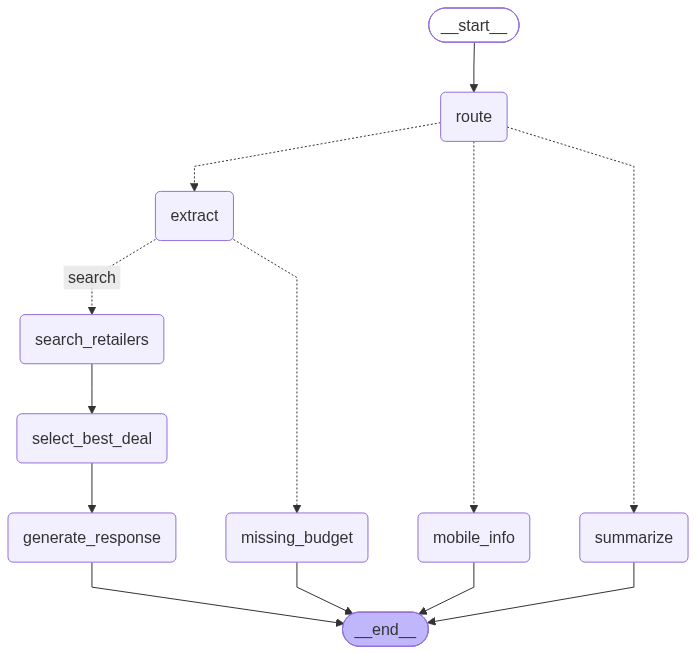

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
config = {
        "configurable": {
            "thread_id": "wer-123"
        }
    }

In [ ]:
q="oneplus 13 12gb 256gb ram best deal"
try:

        result = graph.invoke(
            {
                "user_query": q
            },
            config=config
        )

        best_deal = result.get("best_deal")

        output={
            "query": q,

            "extracted": (
                result["extracted_query"].model_dump()
            ),

            "best_deal": (
                best_deal.model_dump()
                if best_deal
                else None
            ),

            "alternatives": [
                deal.model_dump()
                for deal in result.get(
                    "alternatives",
                    []
                )
            ],

            "response": result.get(
                "response",
                ""
            )
        }

        print (output)
except Exception as exc:

    raise HTTPException(
    status_code=500,
    detail=str(exc)
    )


In [ ]:
print(output['response'])

In [ ]:
print(output['response'])

In [ ]:
from IPython.display import display, Markdown

# text = """
# # Deal Agent

# This is a **LangGraph** application.

# ## Steps

# - Extract product information
# - Search for deals
# - Select the best deal
# - Generate the final response
# """

display(output['response'])